# ***ANÁLISIS EXPLORATORIO DE DATOS (EDA)***

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, StandardScaler
import seaborn as sns
import os
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('../data/diabetic_data.csv', sep=",", quotechar='"')

## 1- Estadística Descriptiva

In [3]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


En la tabla anterior, donde se obtiene un resumen estadístico del dataset, se observa que contiene 101.766 registros, por lo que se trata de un conjunto de datos bastante grande y adecuado para entrenar modelos de aprendizaje automático. Se puede ver que hay columnas, como por ejemplo **"encounter_id"** y **"patient_nbr"**, que aparecen como numéricas, pero realmente son identificadores, así que los valores de la tabla (media, desviación típica...) no aportan infrmación relevante.

En cuanto al resto de variables, **"time_in_hospital"** tiene una media de aproximadamente 4.4 días, con valores entre 1 y 14 días, lo que indica que la mayoría de pacientes permanecen pocos días ingresados, aunque existen casos con estancias más largas.

La variable **"num_lab_procedures"** muestra una media de unas 43 pruebas de laboratorio, con un mínimo de 1 y un máximo de 132. Esto refleja que hay bastante variabilidad entre pacientes, de forma que algunos requieren muy pocas pruebas, mientras que otros tienen un seguimiento mucho más intenso. También se observa que el número de procedimientos médicos (**"num_procedures"**) suele ser bajo, ya que la media es aproximadamente 1.34, la mediana es 1 y el máximo es 6. Esto sugiere que un ingreso no implica una gran cantidad de procedimientos, aunque sí existen pacientes con mayor intervención.

Respecto a la medicación, **"num_medications"** tiene una media de 16 aproximadamente, con valores desde 1 hasta 81. Esta diferencia entre el mínimo y el máximo muestra que hay pacientes con tratamientos muy simples y otros que necesitan una cantidad de fármacos mucho mayor, algo esperable en el contexto del problema ya que entre los pacientes diabéticos pueden haber mucha variabilidad en este caso según las necesidades individuales.

Las variables **"number_outpatient"**, **"number_emergency"** y **"number_inpatient"** tienen medianas de 0, lo que indica que al menos la mitad de los pacientes no tuvieron visitas ambulatorias, de emergencia o ingresos previos. Sin embargo, los máximos son altos (**"number_emergency"** con 76, **"number_outpatient"** con 42 y **"number_inpatient**" con 21), lo que muestra algunos pacientes con un historial más complejo, lo cual es relevante para estudiar el riesgo de readmisión.

Por último, **"number_diagnoses"** tiene una media de aproximadamente 7.42 diagnósticos, con una mediana de 8 y un máximo de 16. Esto indica que muchos pacientes obtienen varios diagnósticos. Esta variable puede ser importante para el modelo, ya que un mayor número de diagnósticos puede estar relacionado con peor estado de salud general, y por lo tanto con mayor probabilidad de reingreso.

En general, este análisis muestra que el dataset contiene variables clínicas útiles para estudiar la readmisión hospitalaria. Además de que se observa que algunas variables presentan valores extremos, por lo que será necesario analizarlas con más detalle durante el EDA.

## 2- Distribuciones Univariadas

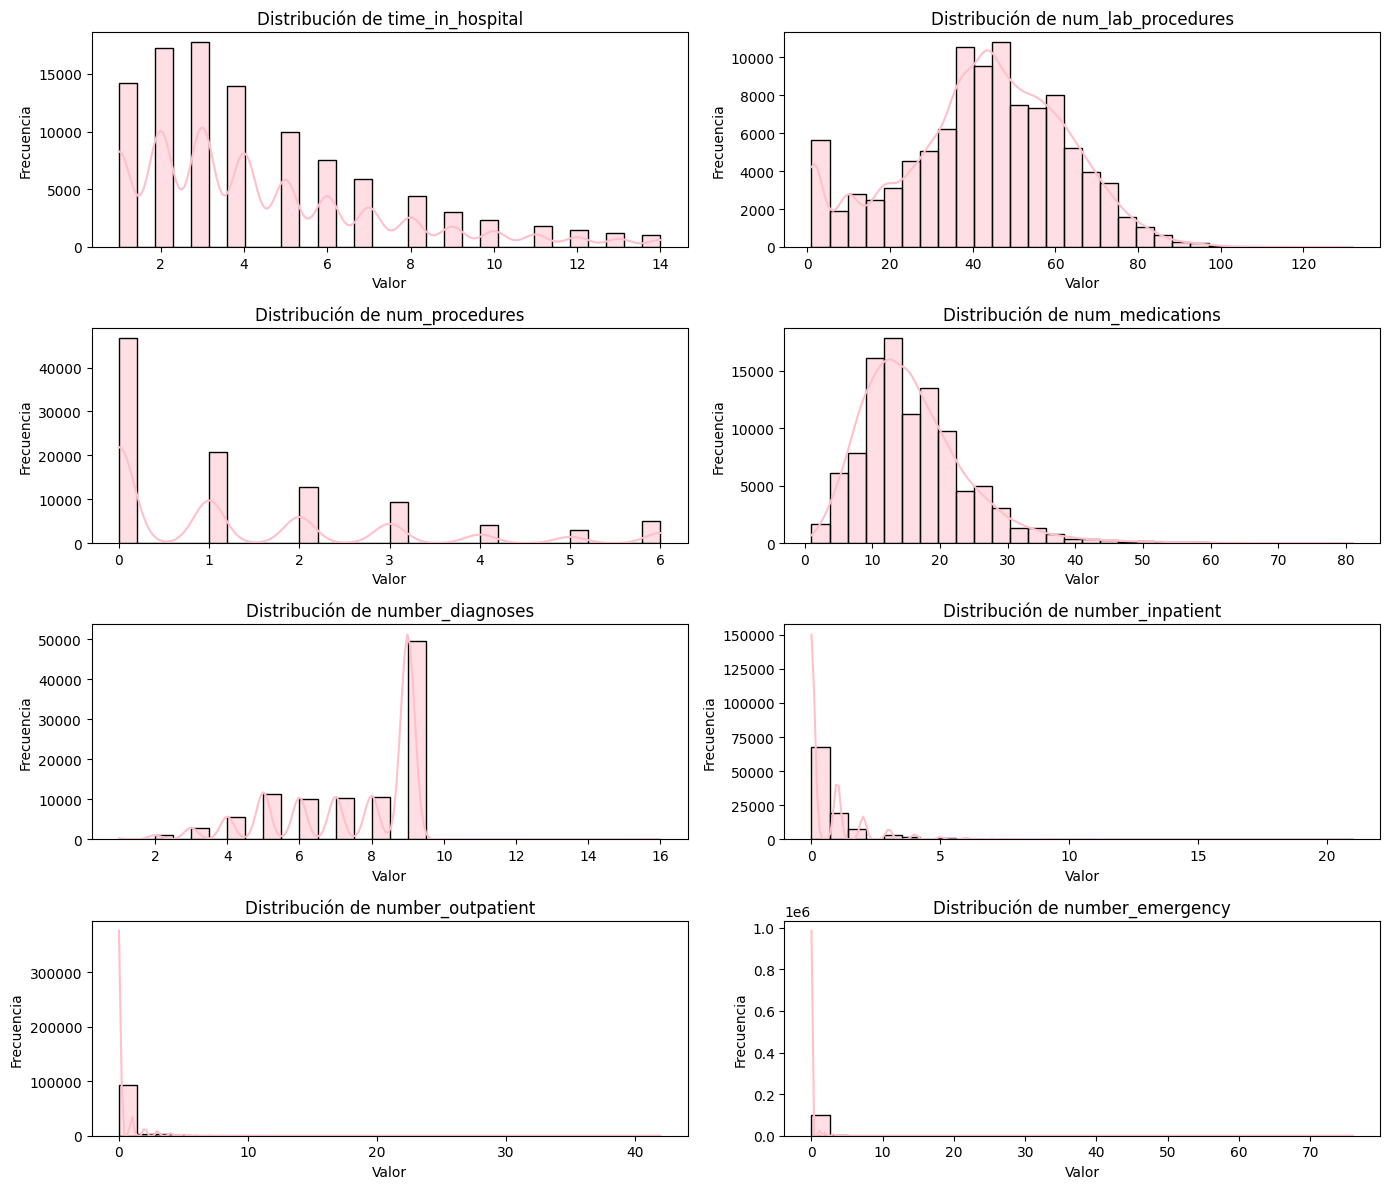

In [4]:
cols_analisis = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures', 
    'num_medications', 'number_diagnoses', 'number_inpatient', 
    'number_outpatient', 'number_emergency'
]

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, feature in enumerate(cols_analisis):
    sns.histplot(data=df, x=feature, kde=True, bins=30, ax=axes[idx], color='pink')
    axes[idx].set_title(f'Distribución de {feature}', fontsize=12)
    axes[idx].set_xlabel('Valor', fontsize=10)
    axes[idx].set_ylabel('Frecuencia', fontsize=10)

plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.tight_layout()
plt.savefig("../visualizacion_eda/distr_univariada.png", bbox_inches='tight', dpi=100)
plt.show()  

En la imagen anterior se muestran las distribuciones de las variables numéricas del dataset, lo cual es útil porque permite ver cómo se reparten los valores de cada variable antes de aplicar transformaciones.

En la variable **"time_in_hospital"**, se observa que la mayoría de pacientes permanecen ingresados pocos días, de forma que la distribución se concentra sobre todo entre 1 y 5 días, y a partir de ahí la frecuencia va disminuyendo. Es decir, se observa una distribución sesgada hacia la derecha, lo que demuestra que los pacientes diagnosticados con diabetes suelen tener ingresos bastante cortos, y en casos menos comunes se tienen estancias más largas. Esta variable es relevante para el modelo, porque una estancia más larga puede estar relacionada con una mayor gravedad del paciente.

La variable **"num_lab_procedures"** muestra una distribución más centrada. La mayoría de pacientes se sitúan aproximadamente entre 30 y 60 procedimientos de laboratorio, con un pico alrededor de los 40-50. También se observa una cola hacia la derecha, ya que hay pacientes con un número bastante más alto de pruebas. Esta información es muy útil porque nos muestra aquellos pacientes que necesitaron un mayor seguimiento en pruebas de laboratorio y con ello información útil sobre la complejidad del ingreso.

En la variable **"num_procedures"** se aprecia que solo toma valores entre 0 y 6. La mayor parte de los pacientes tiene valor 0, lo que significa que no se les realizaron procedimientos médicos adicionales aparte de pruebas de laboratorio. Después aparecen frecuencias menores en el resto de los casos. Esto tiene sentido porque no todos los ingresos requieren procedimientos médicos adicionales más allá de pruebas, observación o tratamiento farmacológico. Sin embargo, los pacientes con varios procedimientos pueden representar casos más graves, por lo que esta variable también aporta información útil.

La distribución de **"num_medications"** se concentra principalmente entre 10 y 20, y tiene una forma parecida a una campana, aunque con cierta asimetría hacia la derecha. Esto quiere decir que la mayoría de pacientes reciben un número de medicamentos similar, pero también existe un grupo más pequeño con muchas medicaciones, llegando a valores bastante altos. Estos casos corresponden a pacientes con tratamientos más complejos, por lo que esta variable puede ser importante para predecir el riesgo de reingreso.

La variable **"number_diagnoses"** muestra una concentración muy alta en 9 diagnósticos. También aparecen valores entre 1 y 8, pero el pico principal está en 9. Esto indica que muchos pacientes tienen varios diagnósticos registrados, algo esperable en este contexto, ya que los pacientes diabéticos pueden tener otras enfermedades o complicaciones asociadas, que como se observa en la distribución es lo habitual. Por tanto, esta variable es relevante porque refleja el nivel de complejidad del paciente.

Las variables **"number_inpatient"**, **"number_outpatient"** y **"number_emergency"** mujestran distribuciones muy sesgadas hacia la derecha. En las tres se observa una gran concentración de valores bajos, especialmente en 0, y una cola larga con pocos pacientes que tienen valores elevados. Esto significa que la mayoría de pacientes no tuvo visitas previas o tuvo muy pocas, lo cual es habitual porque muchos pacientes tienen un uso puntual del sistema sanitario.

En el caso de **"number_inpatient"**, la concentración en valores bajos indica que muchos pacientes no habían tenido ingresos hospitalarios previos. Sin embargo, los pacientes con valores más altos pueden ser importantes, porque haber tenido ingresos previos suele estar relacionado con mayor probabilidad de volver a ingresar. Asimismo, la variable **"number_outpatient"** muestra que la mayoría de pacientes tuvo pocas visitas ambulatorias previas, pero hay un grupo reducido que sí acudió varias veces.

Por último, la variable **"number_emergency"** indica que la mayoría de pacientes no acudió a urgencias o acudió pocas veces, mientras que algunos pacientes fueron varias veces. Esta variable puede ser especialmente útil porque acudir muchas veces a urgencias suele indicar inestabilidad clínica o problemas no resueltos. Por tanto, aunque los valores altos sean poco frecuentes, pueden ser muy informativos.

## 3- Box Plots

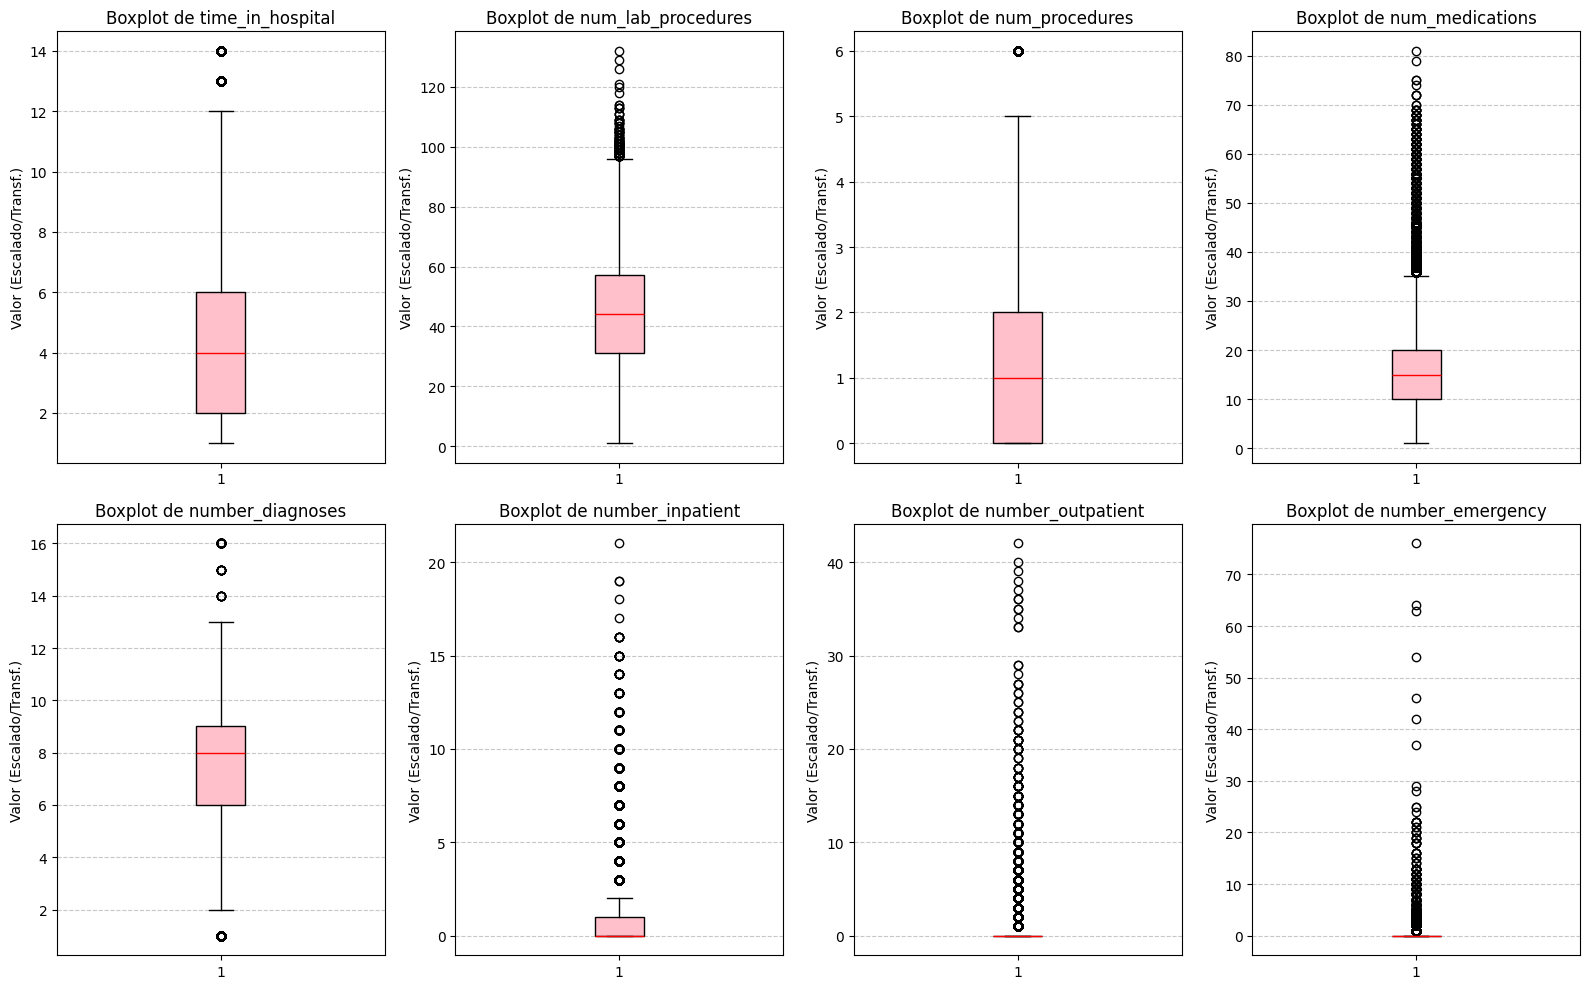

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten() # Aplanamos para iterar fácilmente

for idx, feature in enumerate(cols_analisis):
    # Dibujamos el boxplot. Usamos patch_artist para poder darle color.
    axes[idx].boxplot(df[feature], patch_artist=True, 
                      boxprops=dict(facecolor='pink', color='black'),
                      medianprops=dict(color='red'))
    
    axes[idx].set_title(f'Boxplot de {feature}', fontsize=12)
    axes[idx].set_ylabel('Valor (Escalado/Transf.)')
    axes[idx].grid(axis='y', linestyle='--', alpha=0.7)

# 2. Ajuste de márgenes para que no se pisen los títulos
plt.tight_layout()
plt.savefig('../visualizacion_eda/boxplots_analisis.png', dpi=300, bbox_inches='tight')
plt.show()

En los boxplots se puede observar mejor la presencia de valores atípicos. El análisis de estos gráficos es útil porque permite ver dónde se concentran la mayoría de los datos y qué variables tienen valores extremos que podrían influir en los modelos.

En **"time_in_hospital"**, se observa que la mediana está alrededor de 4 días y la mayor parte de los valores se sitúan entre 2 y 6. También aparecen algunos valores por encima del rango (no una gran cantidad), en estancias de 13 y 14 días, que se consideran valores atípicos según el criterio del boxplot. Aun así, estos valores no se consideran errores, sino pacientes que necesitaron una hospitalización más larga, posiblemente por mayor gravedad, información la cual es puede ser útil en el contexto del problema.

En **"num_lab_procedures"**, la mediana está un poco por encima de las 40 pruebas, y la mayoría de pacientes se concentran aproximadamente entre 30 y 57 procedimientos de laboratorio. Se observan bastantes valores atípicos en la parte superior, por encima de unas 95 pruebas aproximadamente, llegando hasta más de 120. Esto indica que algunos pacientes necesitan muchas más pruebas de laboratorio que la mayoría, lo que puede reflejar casos clínicos más complejos o con mayor seguimiento durante el ingreso. Dado que se observan valores extremos que pueden afectar en el modelo, es conveniente aplicar una transformación que como se puede ver en el preprocesamiento se aplica RobustScaling, ya que en la distribución de la variable analizada anteriormente se ha podido comprobar que no es extremadamente asimétrica.

La variable **"num_procedures"** tiene una mediana de 1 y la mayoría de valores se encuentran entre 0 y 2. El máximo habitual llega hasta 5, y aparece algún valor atípico en 6. Esto confirma que la mayoría de pacientes tuvieron pocos procedimientos médicos, y que los casos con muchos procedimientos son menos frecuentes, de hecho en el gráfico no se observa que la presencia de outliers sea muy significativa porque solo se ve un punto, por lo tanto en este caso se podrá ver en e preprocesamiento que la variable se deja tal cual porque la información que aporta es importante y la cantidad de outliers no es tan grande.

En **"num_medications"**, la mediana está alrededor de 15 medicamentos, con la mayoría de pacientes entre 10 y 20. Sin embargo, se observa una gran cantidad de valores atípicos por encima de unos 35 medicamentos, llegando incluso a más de 80. Estos valores pueden representar pacientes con una situación más compleja o con varias enfermedades asociadas. Por tanto, aunque no deberían eliminarse porque pueden contener información importante, es importante tenerlos en cuenta y tratarlos para que no afecten al modelo.

La variable **"number_diagnoses"** obtiene una mediana de 8 diagnósticos y la mayoría de valores se sitúan aproximadamente entre 6 y 9. Hay algunos valores atípicos tanto por debajo como por encima, llegando hasta 16 diagnósticos. Esto muestra que muchos pacientes tienen varios diagnósticos registrados, pero también existen casos con una cantidad especialmente alta. Esta variable puede ser relevante porque resume, en cierta forma, la complejidad clínica del paciente.

En **"number_inpatient"**, se observa una distribución muy concentrada en valores bajos, especialmente en 0. La caja es muy pequeña y aparecen muchos valores atípicos por encima, llegando hasta más de 20 ingresos previos. Esto indica que la mayoría de pacientes no tuvo ingresos previos, pero existe un grupo reducido con varios ingresos anteriores. Estos casos pueden ser muy importantes para el problema, ya que un historial de ingresos previos puede estar relacionado con mayor probabilidad de reingreso, sin embargo es importante tener en cuenta que estos valores son outliers y tratarlos de forma adecuada en el preprocesamiento.

La variable **"number_outpatient"** muestra un patrón todavía más extremo. La mayoría de los valores están en 0, por eso la caja queda prácticamente comprimida en la parte inferior. Sin embargo, aparecen muchos valores atípicos, llegando hasta más de 40 visitas ambulatorias. Esto significa que casi todos los pacientes tuvieron pocas o ninguna visita ambulatoria previa, pero hay algunos pacientes con un uso muy frecuente del sistema sanitario, información que puede ser de gran utilidad pero también debe ser tratada adecuadamente para no tener un impacto negativo en el modelo.

Por último, **"number_emergency"** también está muy concentrada en 0 y presenta una gran cantidad de valores atípicos hacia arriba, incluso por encima de 70 visitas a urgencias. Esto muestra que la mayoría de pacientes no acudió a urgencias previamente, pero algunos casos presentan un número muy elevado de visitas. Estos valores extremos pueden ser especialmente relevantes, ya que muchas visitas a urgencias pueden indicar inestabilidad o problemas de salud mal controlados, pero al igual que antes hay que tratar los outliers adecuadamente.

## 4- Relaciones Bivariadas

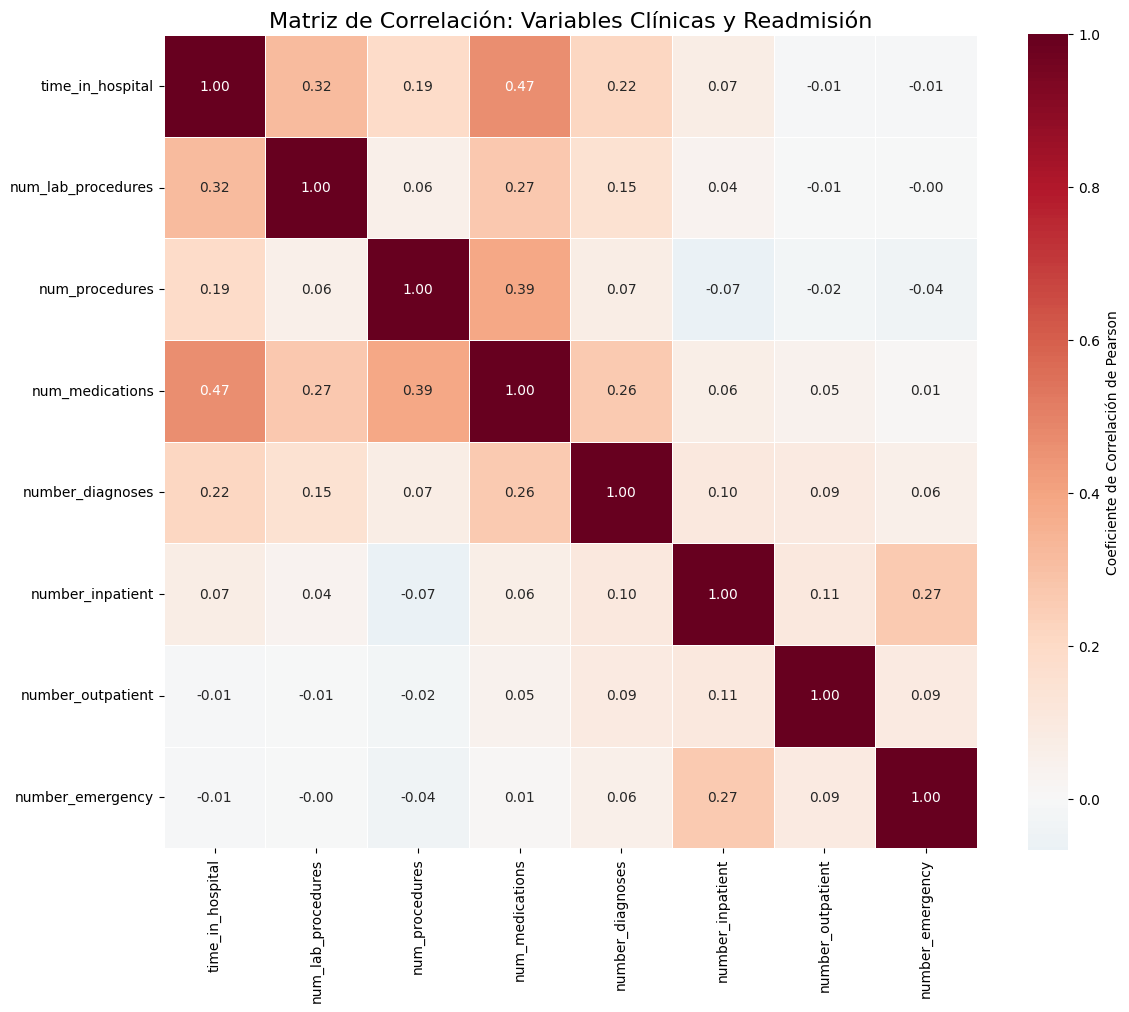

In [4]:
cols_analisis = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures', 
    'num_medications', 'number_diagnoses', 'number_inpatient', 
    'number_outpatient', 'number_emergency'
]

# Calculamos la matriz solo para esas columnas
corr_matrix = df[cols_analisis].corr()

# Visualización 
fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    corr_matrix, 
    annot=True,         
    fmt='.2f',          
    cmap='RdBu_r',      
    center=0,           
    square=True, 
    linewidths=0.5,       
    ax=ax, 
    cbar_kws={'label': 'Coeficiente de Correlación de Pearson'}
)

ax.set_title('Matriz de Correlación: Variables Clínicas y Readmisión', fontsize=16)

# Guardado y cierre
plt.tight_layout()
plt.savefig('../visualizacion_eda/correlacion_matrix_diabetes.png', dpi=300, bbox_inches='tight')
plt.show()

La matriz de correlación muestra que, en general, no existen correlaciones muy altas entre las variables analizadas, lo cual es positivo porque indica que la mayoría de variables aportan información distinta sobre el paciente. Aun así, sí aparecen algunas relaciones moderadas que tienen bastante sentido dentro del contexto del problema.

La relación más destacada se observa entre **"time_in_hospital"** y **"num_medications"**, con una correlación de 0.47. Esto indica que los pacientes que pasan más días ingresados suelen recibir un mayor número de medicamentos, lo cual es esperable, ya que una estancia hospitalaria más larga normalmente implica más seguimiento médico y más tratamientos. En cuanto a la predicción de readmisión, esta variable puede ser importante porque un paciente que necesita más medicación o más días de hospitalización podría estar asociado a un estado de salud más delicado.

También se observa una correlación moderada entre **"num_procedures"** y **"num_medications"**, con un valor de 0.39. Esto puede interpretarse como que los pacientes a los que se les realizan más procedimientos médicos también tienden a recibir más medicación. De nuevo esto tiene sentido, porque un mayor número de procedimientos suele estar relacionado con casos más complejos, y con ello tratamientos más intensivos.

Otra relación relevante aparece entre **"time_in_hospital"** y **"num_lab_procedures"**, con una correlación de 0.32. De forma que los pacientes que permanecen más tiempo ingresados suelen requerir más pruebas de laboratorio. Esto puede deberse a que, durante una estancia más larga, se realizan más controles para monitorizar la evolución del paciente.

También existe cierta relación entre **"num_medications"** y **"num_lab_procedures"**, con una correlación de 0.27, y entre **"num_medications"** y **"number_diagnoses"**, con una correlación de 0.26. Estas asociaciones sugieren que los pacientes con más diagnósticos o con mayor seguimiento mediante pruebas de laboratorio suelen recibir más medicación.

Por otro lado, las variables relacionadas con visitas previas al sistema sanitario, como **"number_inpatient"**, **"number_outpatient"** y **"number_emergency"**, presentan correlaciones más bajas con la mayoría de variables que tienen que ver con la información del ingreso actual. La relación más clara dentro de este grupo es entre **"number_inpatient"** y **"number_emergency"**, con una correlación de 0.27. Esto puede indicar que algunos pacientes tienen un uso más frecuente del sistema sanitario, tanto por ingresos previos como por visitas a urgencias. En un problema de readmisión, este aspecto puede ser importante, ya que un historial de ingresos o urgencias puede reflejar pacientes con mayor riesgo de volver al hospital.

En cambio, la variable **"number_outpatient"** no muestra correlaciones fuertes con el resto. Esto puede deberse a que las visitas ambulatorias no siempre reflejan gravedad. Un paciente puede tener muchas visitas externas por seguimiento o prevención de la enfermedad, sin que eso implique un caso más complejo.

En general, la matriz muestra que las variables más relacionadas entre sí son las que describen la intensidad de la atención durante el ingreso, que son las que parecen estar asociadas a la complejidad del caso. Sin embargo, como las correlaciones no son muy altas, no parece haber redundancia entre ellas.

## 5- Scatter Plots

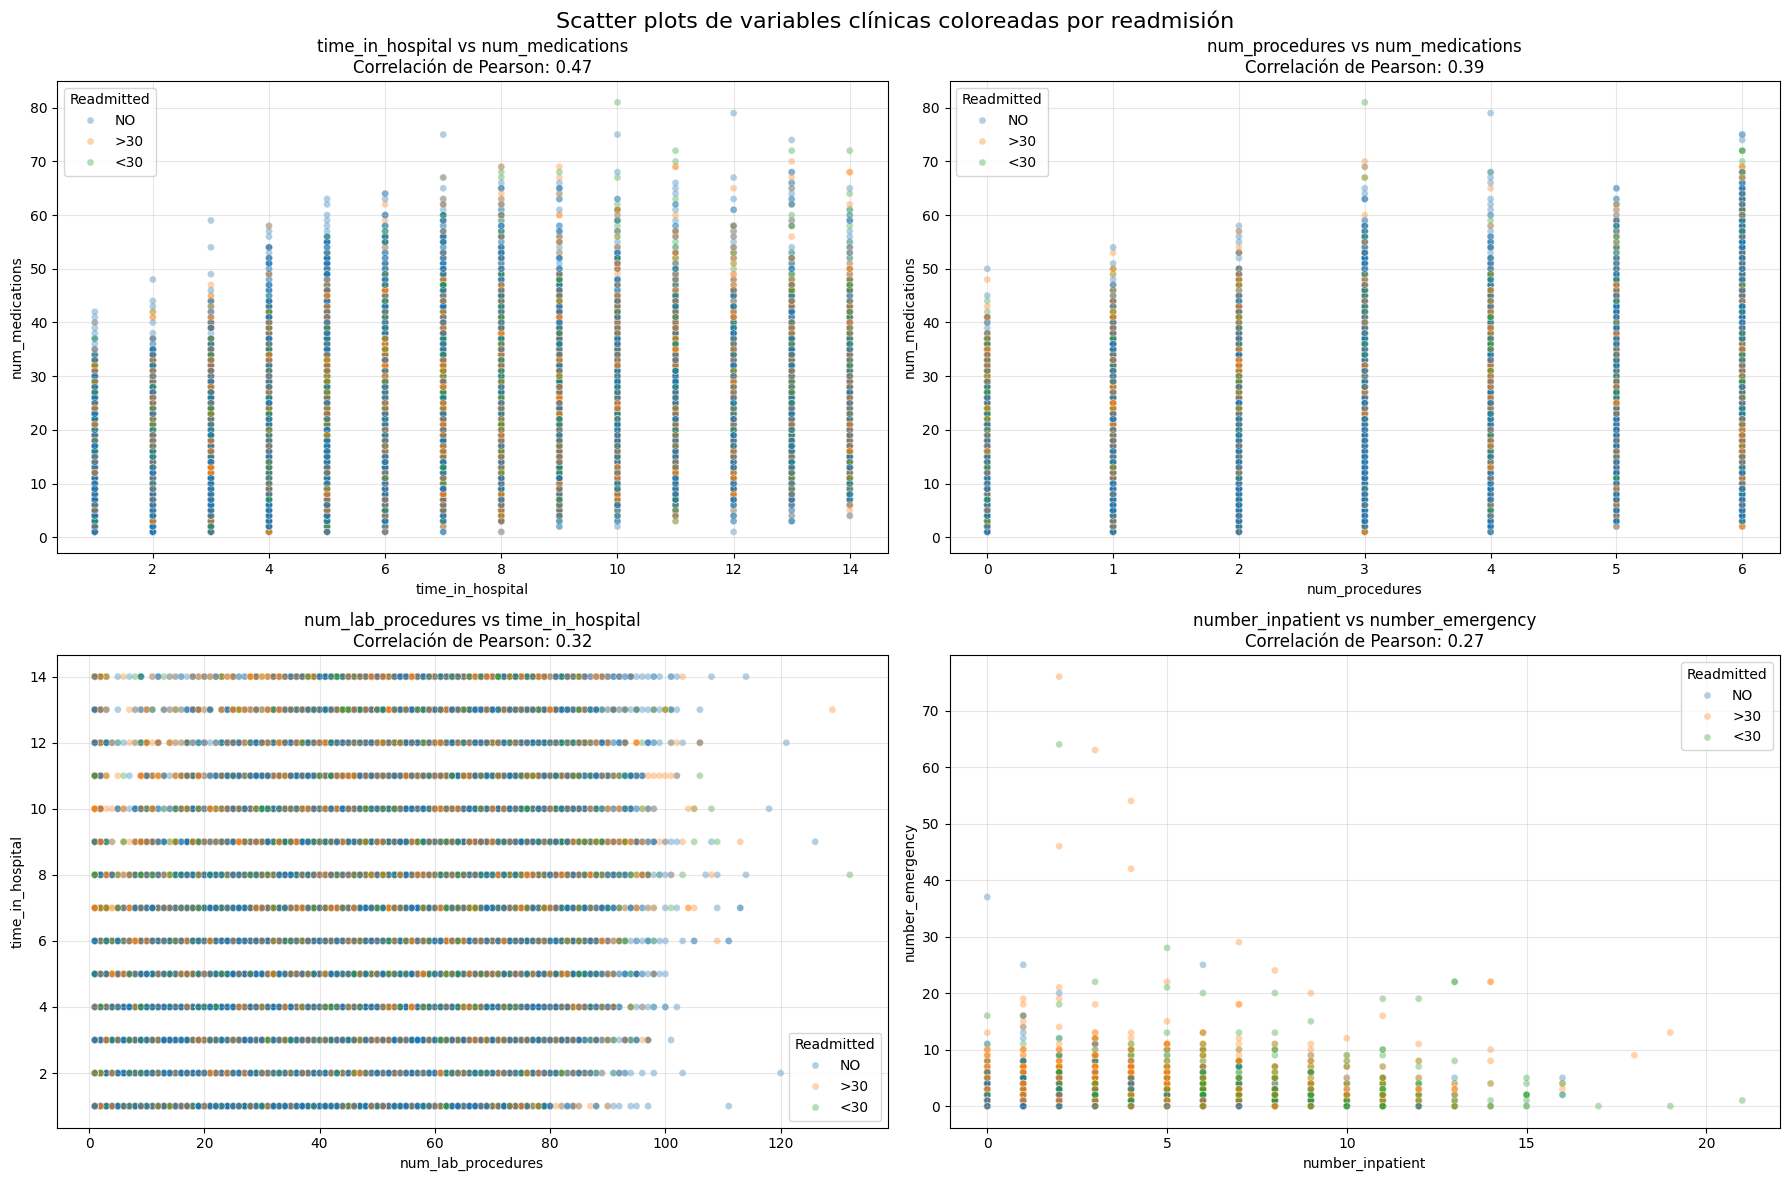

In [ ]:
# Pares de variables numéricas a analizar
scatter_pairs = [
    ("time_in_hospital", "num_medications"),
    ("num_procedures", "num_medications"),
    ("num_lab_procedures", "time_in_hospital"),
    ("number_inpatient", "number_emergency")
]

# Comprobamos que las columnas existen
missing_cols = []
for x_col, y_col in scatter_pairs:
    if x_col not in df.columns:
        missing_cols.append(x_col)
    if y_col not in df.columns:
        missing_cols.append(y_col)

if "readmitted" not in df.columns:
    missing_cols.append("readmitted")

if missing_cols:
    raise ValueError(f"Faltan columnas en el dataframe: {set(missing_cols)}")

# Figura con scatter plots coloreados por readmitted
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for ax, (x_col, y_col) in zip(axes, scatter_pairs):
    corr = df[[x_col, y_col]].corr(method="pearson").iloc[0, 1]

    sns.scatterplot(
        data=df,
        x=x_col,
        y=y_col,
        hue="readmitted",
        alpha=0.35,
        s=25,
        ax=ax
    )

    ax.set_title(f"{x_col} vs {y_col}\nCorrelación de Pearson: {corr:.2f}")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.grid(True, alpha=0.3)
    ax.legend(title="Readmitted")

plt.suptitle("Scatter plots de variables clínicas coloreadas por readmisión", fontsize=16)
plt.tight_layout()
plt.savefig('../visualizacion_eda/scatter_plots_readmitted.png', dpi=300, bbox_inches='tight')
plt.show()

## 6- Multicolinealidad

En cuanto a la multicolinealidad, ya se ha explicado que no se detectan relaciones lineales fuertes entre las variables. En este caso, no se observan coeficientes de correlación superiores a 0.9 (umbral habitual para considerar que hay multicolinealidad). La mayor correlación observada se da entre "time_in_hospital" y "num_medications", con un valor de 0.47. Por tanto, se concluye que el dataset no presenta problemas de multicolinealidad, lo que permite utilizar modelos lineales sin tener que aplicar técnicas adicionales para solucionarlo.

## 7- Imbalance y Representatividad

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64
readmitted
NO     53.911916
>30    34.928169
<30    11.159916
Name: proportion, dtype: float64


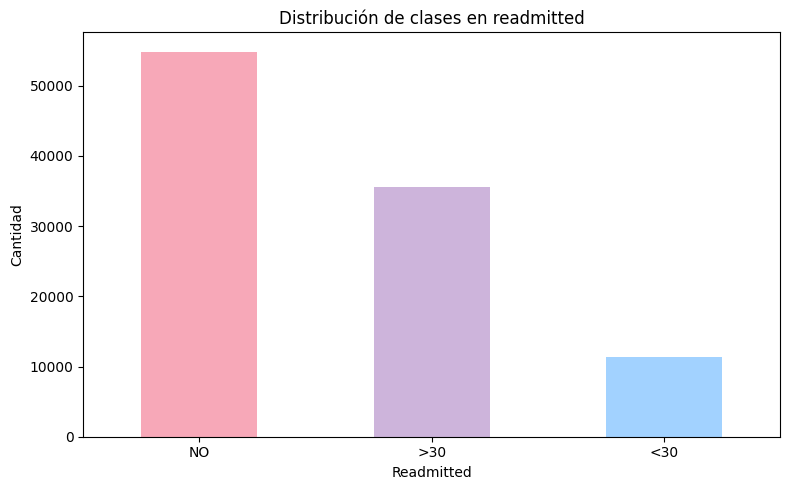

In [10]:
# Conteo de clases
print(df['readmitted'].value_counts())

# Porcentaje de clases
print(df['readmitted'].value_counts(normalize=True) * 100)

# Visualización
fig, ax = plt.subplots(figsize=(8, 5))

df['readmitted'].value_counts().plot(
    kind='bar',
    ax=ax,
    color=['#F7A8B8', '#CDB4DB', '#A2D2FF'] 
)

ax.set_title('Distribución de clases en readmitted')
ax.set_xlabel('Readmitted')
ax.set_ylabel('Cantidad')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('../visualizacion_eda/imbalance.png', dpi=300, bbox_inches='tight')
plt.show()

## 8- Patrones, Anomalías e Insights

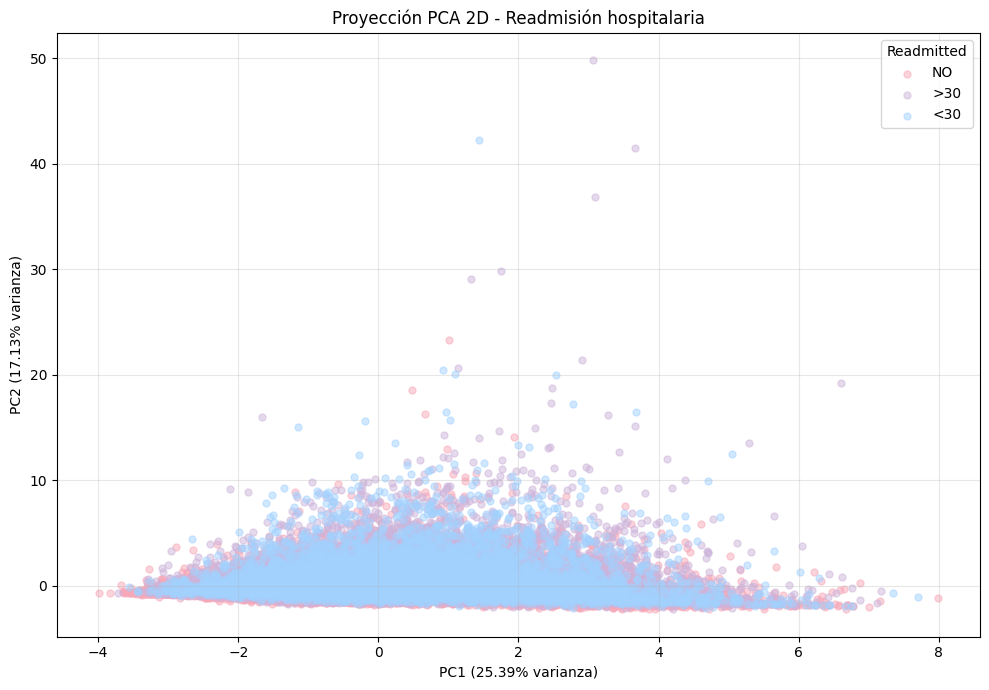

In [12]:
# Variables numéricas que vamos a usar para la proyección PCA
features = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_diagnoses',
    'number_inpatient',
    'number_outpatient',
    'number_emergency'
]

# Nos quedamos solo con esas variables
X = df[features].copy()

# Estandarización: importante para PCA porque las variables tienen escalas distintas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA a 2 componentes
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Visualización
fig, ax = plt.subplots(figsize=(10, 7))

colors = {
    'NO': '#F7A8B8',    # rosa pastel
    '>30': '#CDB4DB',   # lila pastel
    '<30': '#A2D2FF'    # azul pastel
}

for clase in df['readmitted'].unique():
    mask = df['readmitted'] == clase
    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=clase,
        s=25,
        alpha=0.5,
        color=colors.get(clase)
    )

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} varianza)')
ax.set_title('Proyección PCA 2D - Readmisión hospitalaria')
ax.legend(title='Readmitted')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizacion_eda/pca_visualization.png', dpi=300, bbox_inches='tight')
plt.show()